# Propagación de costos en CGV, procedencia y límites de validación del bienestar

**¿Cómo se propaga el aumento de costos de un proveedor a lo largo de una cadena global de valor (CGV), y quién paga un arancel sobre bienes importados?** La segunda pregunta también muestra cómo distinguir un contrafactual comercial resuelto de una afirmación de bienestar sin sustento: el PIB nominal y la recaudación arancelaria no son bienestar, y una cifra de bienestar vale lo que valen su cierre y su numerario.

Todos los datos son sintéticos y didácticos. La primera mitad usa tablas pequeñas generadas con la estructura de las bases OECD Inter-Country Input-Output (ICIO), FIGARO de Eurostat y EXIOBASE; no son observaciones de esas bases. La segunda mitad usa una tabla de dos países balanceada a mano.

## El método en matemáticas

Un nodo es un par país-sector. Sea $Z_{ij}$ la compra del nodo $j$ al nodo $i$ y $X_j$ la producción bruta del nodo $j$. El coeficiente de insumo $A_{ij}=Z_{ij}/X_j$ es la compra al proveedor $i$ por unidad de producción del comprador $j$. Con coeficientes fijos, los costos unitarios cumplen $p=A^Tp+v$, de modo que un cambio $dv$ en el costo primario por unidad de producción mueve los precios en

$$dp=(I-A^T)^{-1}dv=dv+A^Tdv+(A^T)^2dv+\cdots$$

El término $k$ es el aumento de costos que ya atravesó $k$ capas de clientes. La serie converge cuando el radio espectral cumple $\rho(A)<1$, lo que para una $A$ no negativa equivale a la condición de productividad de Hawkins–Simon. Este cálculo mantiene fijos los precios de los factores y los impuestos por unidad. (En la biblioteca los impuestos a la producción son ad valorem, $p=D(A^Tp+v)$ con $D=\mathrm{diag}(1/(1-t))$, lo que da $dp=(I-DA^T)^{-1}D\,dv$.) El equilibrio general también mueve precios de factores, cantidades, transferencias y recaudación tributaria.

El bienestar usa una función de gasto $e(P,U)$. La variación equivalente $EV=e(P_0,U_1)-e(P_0,U_0)$ valora el cambio de utilidad a precios iniciales; la variación compensatoria $CV=e(P_1,U_1)-e(P_1,U_0)$ lo valora a precios contrafactuales. Ambas son positivas para ganancias. Con una sola canasta de consumo Leontief, $U=C$ y $e(P,U)=PU$, así que $EV=P_0(C_1-C_0)$ y $CV=P_1(C_1-C_0)$.

## Intuición

**Intuición.** El aumento de costos de un proveedor llega a sus clientes a través de sus compras de insumos, luego a los clientes de esos clientes, y cada ronda es más pequeña aproximadamente en el factor $\rho(A)$. Un arancel es un aumento de costos en la frontera. Quién termina pagándolo depende de si los compradores pueden cambiar de proveedor. Con abastecimiento de coeficientes fijos (Leontief) no pueden: el país importador sigue comprando los bienes gravados, sus propios costos suben y el precio relativo del exportador puede incluso aumentar. La variación equivalente convierte los precios y cantidades finales en una medida monetaria solo cuando se declaran la función de gasto, el cierre fiscal, el cierre del ahorro externo y el numerario.

## Código resuelto

Generamos los datos de forma explícita y mostramos su procedencia antes de reportar resultados.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd() if (Path.cwd() / "puremacro").is_dir() else Path.cwd().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))
sys.path.insert(0, str(repo / "notebooks"))
import _nbstyle
_nbstyle.apply_style()
from puremacro.trade.data import load_exiobase, load_figaro, load_oecd_icio_granular
from puremacro.trade import calibrate_trade_model, solve_trade_equilibrium, compute_hicksian_welfare
from puremacro.trade.regularize import compute_spectral_radius

### Procedencia

Los lectores de datos reales requieren por defecto un archivo fuente; `fallback_to_synthetic=True` es una autorización explícita para usar tablas generadas. Las tres estructuras siguientes salen de un mismo generador. El nombre del proveedor fija las etiquetas de países y sectores, la lista de usos finales y la moneda, no los coeficientes, de modo que con tres países y tres sectores las tres matrices de coeficientes son idénticas por construcción; la celda lo verifica. La tabla muestra lo que registra cada calibración: las estructuras FIGARO y EXIOBASE se generan en millones de euros y se convierten con un tipo de cambio supuesto, la participación del trabajo en el valor agregado es un supuesto por defecto, y el balanceo cambia los flujos solo al nivel del redondeo.

In [2]:
loaders = {"oecd": load_oecd_icio_granular, "figaro": load_figaro, "exiobase": load_exiobase}
# Synthetic provider layouts; each loader condenses the final uses before calibrating.
calibrations = {source: loader(custom_c=3, custom_s=3, seed=42, fallback_to_synthetic=True)
                for source, loader in loaders.items()}
provenance = pd.DataFrame([
    {"layout": name, "source": c.metadata["source"], "synthetic": c.metadata["is_synthetic"],
     "seed": c.metadata["seed"], "unit": c.metadata["unit"],
     "generated_in": c.metadata.get("original_unit") or c.metadata["unit"],
     "usd_per_eur": c.metadata.get("exchange_rate_usd_per_eur") or np.nan,
     "labor_share_of_va": round(c.metadata["labor_share_assumption"], 4),
     "balancing_below_1e-9": max(v["max_abs_change"] for v in c.metadata["adjustments"].values()) < 1e-9}
    for name, c in calibrations.items()
])
print(provenance.to_string(index=False))
assert provenance["synthetic"].all() and provenance["balancing_below_1e-9"].all()
A_by_layout = {name: c.a.reshape(c.n_countries * c.n_sectors, -1, order="F") for name, c in calibrations.items()}
layout_gap = max(np.abs(A - A_by_layout["oecd"]).max() for A in A_by_layout.values())
assert layout_gap < 1e-12  # the same network under three label sets
print("Coefficient matrices identical across layouts (max |dA| < 1e-12):", layout_gap < 1e-12)
min_share = min(c.theta.min() for c in calibrations.values())
print(f"Smallest final-use expenditure share in the provider layouts: {min_share:.4f}")

  layout             source  synthetic  seed  unit generated_in  usd_per_eur  labor_share_of_va  balancing_below_1e-9
    oecd     Synthetic_OECD       True    42 M_USD        M_USD          NaN             0.6667                  True
  figaro   Synthetic_FIGARO       True    42 M_USD        M_EUR       1.1195             0.6667                  True
exiobase Synthetic_EXIOBASE       True    42 M_USD        M_EUR       1.1195             0.6667                  True
Coefficient matrices identical across layouts (max |dA| < 1e-12): True
Smallest final-use expenditure share in the provider layouts: -0.1070


### Propagación de costos con precios fijos

Como las tres estructuras comparten una misma red, la cascada se calcula una sola vez, con las etiquetas de la estructura OECD. Un aumento de 1% en el costo unitario afecta al primer nodo. La cota espectral superior certifica $\rho(A)<1$; reconstruir la cascada ronda a ronda (la serie de arriba) y compararla con la solución lineal directa es una verificación de consistencia interna entre dos rutas numéricas, no un oráculo independiente.

In [3]:
cal = calibrations["oecd"]
n = cal.n_countries * cal.n_sectors
A = cal.a.reshape(n, n, order="F")  # A[i, j]: input from node i per unit of node j's output
nodes = [f"{cal.country_codes[k // cal.n_sectors]}_{cal.sector_codes[k % cal.n_sectors]}" for k in range(n)]
rho, lower, upper = compute_spectral_radius(A)
assert upper < 1.0  # certifies rho(A) < 1, so the cascade converges
shock_node, shock_size = 0, 0.01
dv = np.zeros(n); dv[shock_node] = shock_size
dp = np.linalg.solve(np.eye(n) - A.T, dv)  # factor prices and per-unit taxes held fixed
partial, layer, gaps = np.zeros(n), dv.copy(), []
for _ in range(40):  # add one layer of customers per round
    partial, layer = partial + layer, A.T @ layer
    gaps.append(np.abs(partial - dp).max())
decay = gaps[20] / gaps[19]
assert gaps[-1] < 1e-14 and abs(decay - rho) < 0.01  # internal check: the series reproduces the solve
home = np.arange(n) // cal.n_sectors == shock_node // cal.n_sectors
indirect = dp - dv  # everything beyond the direct shock
cascade = pd.DataFrame({"home_country": home, "pass_through": dp / shock_size}, index=pd.Index(nodes, name="node"))
print(cascade.round(4).to_string())
print(f"Spectral radius bounds [{lower:.4f}, {upper:.4f}]; each round shrinks the gap by {decay:.4f}")
print(f"Own-node pass-through {dp[shock_node] / shock_size:.4f}; total over all nodes {dp.sum() / shock_size:.4f}")
split = {"own-node feedback": indirect[shock_node], "other home sectors": indirect[home].sum() - indirect[shock_node],
         "foreign nodes": indirect[~home].sum()}
print("Split of the indirect increase:", {k: f"{v / indirect.sum():.1%}" for k, v in split.items()})

            home_country  pass_through
node                                  
ARG_A01_02          True        1.2555
ARG_A03             True        0.0925
ARG_B05_06          True        0.0578
AUS_A01_02         False        0.0704
AUS_A03            False        0.0279
AUS_B05_06         False        0.0218
AUT_A01_02         False        0.0492
AUT_A03            False        0.0224
AUT_B05_06         False        0.0168
Spectral radius bounds [0.3870, 0.3870]; each round shrinks the gap by 0.3876
Own-node pass-through 1.2555; total over all nodes 1.6143
Split of the indirect increase: {'own-node feedback': '41.6%', 'other home sectors': '24.5%', 'foreign nodes': '33.9%'}


### Un experimento arancelario resuelto

Las estructuras de proveedores no sirven para el experimento de bienestar. Tras el cierre del saldo exterior de los lectores, la participación de la inversión de un país es negativa (la menor participación impresa arriba), y la contabilidad consistente en la que se apoya la EV hicksiana rechaza participaciones de gasto negativas. Por eso el experimento usa una tabla separada balanceada a mano: dos países, A y B, un bien cada uno, y usos finales divididos en consumo (C) e inversión (I), en una sola unidad monetaria. El valor agregado se reparte 2/3 para el trabajo y 1/3 para el capital, el supuesto por defecto de los lectores. El ahorro externo inicial no es nulo: A tiene un superávit comercial de 14 y B un déficit de 14 (se imprime abajo).

**Experimento.** El país A aplica un arancel ad valorem de 10% a todas las importaciones desde B, tanto de insumos intermedios como de bienes finales; B no aplica ninguno. La recaudación se devuelve a los hogares de A como transferencia de suma fija. El abastecimiento es Leontief (`sigma=0`, el valor por defecto del solucionador): ningún comprador puede cambiar la mezcla de orígenes de su canasta. Con dotaciones de factores fijas y un bien por país, las cantidades producidas no cambian.

**Unidades, numerario y cierres.** Ambos estados se resuelven con `accounting="consistent"`, el modo contable auditado de la biblioteca: el comercio y los aranceles se valoran a precios al productor, la recaudación de aranceles e impuestos se devuelve como suma fija y los saldos externos iniciales se mantienen fijos. El precio al productor de A es el numerario, igual a uno en ambos estados. El PIB nominal (ingreso de los factores más impuestos a la producción, impuestos a los usos finales y aranceles) y la recaudación arancelaria quedan, por tanto, en unidades del bien de A, y sus cambios dependen de qué país se lista primero. El ahorro externo se mantiene fijo como proporción del ingreso factorial mundial (`foreign_saving_units="world_income"`). El cierre alternativo, que lo fija en unidades del numerario, hace que los resultados reales dependan del orden de los países cuando el ahorro externo no es nulo; la celda de bienestar lo muestra.

In [4]:
# Hand-balanced teaching table: one good per country, values in one currency unit.
Z = np.array([[10., 12.], [8., 14.]])                      # intermediate sales: rows seller A, B; columns buyer A, B
F = np.array([[30., 8., 20., 20.], [15., 15., 50., 18.]])  # final sales to A-C, A-I, B-C, B-I
production_tax = np.array([4., 6.])                        # net production taxes paid by A, B
final_tax = np.array([2., 1., 3., 2.])                     # taxes on A-C, A-I, B-C, B-I purchases


def teaching_table(order=("A", "B")):
    """Rows: goods, net taxes, labor, capital; countries listed in `order` (the first is the numeraire)."""
    k = ["AB".index(code) for code in order]
    cols = [2 * i + j for i in k for j in (0, 1)]
    Zo, Fo, tax = Z[np.ix_(k, k)], F[np.ix_(k, cols)], production_tax[k]
    va = Zo.sum(1) + Fo.sum(1) - Zo.sum(0) - tax  # value added net of production taxes
    return np.vstack([np.hstack([Zo, Fo]), np.r_[tax, final_tax[cols]],
                      np.r_[2 * va / 3, np.zeros(4)], np.r_[va / 3, np.zeros(4)]])


def tariff_experiment(order=("A", "B"), closure="world_income", sigma=0.0, rate=0.10):
    """Solve free trade and A's tariff on all imports from B; return calibration, both states, welfare."""
    calib = calibrate_trade_model(teaching_table(order), ns=1, nc=2, nfd=2,
                                  country_codes=list(order), sector_codes=["GOOD"])
    rates = np.zeros(2); rates[calib.country_codes.index("A")] = rate  # ad valorem RATES by importing country
    options = dict(accounting="consistent", tol=1e-10, sigma=sigma, foreign_saving_units=closure)
    base = solve_trade_equilibrium(calib, **options)
    counterfactual = solve_trade_equilibrium(calib, tau=rates, tau_fd=rates, base_result=base, **options)
    assert base.converged and counterfactual.converged, f"no equilibrium at sigma={sigma}"
    welfare = {code: compute_hicksian_welfare(calib, counterfactual, base_result=base, target_country=code)
               for code in ("A", "B")}
    return calib, base, counterfactual, welfare


print(pd.DataFrame(teaching_table(), index=["A", "B", "net taxes", "labor", "capital"],
                   columns=["A", "B", "A-C", "A-I", "B-C", "B-I"]).round(2).to_string())
calib, base, counterfactual, welfare = tariff_experiment()
print("Baseline foreign saving (A, B):", calib.invforT.ravel())
dq = (counterfactual.c_fd - base.c_fd)[0]  # rows: C, I; columns: A, B (basket quantities)
outcomes = pd.DataFrame({
    "nominal_GDP_%": 100 * (counterfactual.gdp / base.gdp - 1),
    "tariff_revenue": counterfactual.tariffs,
    "C_price_%": 100 * (counterfactual.Pfd_final[0, 0] / base.Pfd_final[0, 0] - 1),
    "I_price_%": 100 * (counterfactual.Pfd_final[0, 1] / base.Pfd_final[0, 1] - 1),
    "consumption_%": 100 * dq[0] / base.c_fd[0, 0],
    "investment_%": 100 * dq[1] / base.c_fd[0, 1],
}, index=pd.Index(calib.country_codes, name="country"))
print(outcomes.round(4).to_string())
p, w = counterfactual.p_sol.ravel(), counterfactual.w_sol.ravel()
p_ratio = p[1] / p[0]
print(f"B's producer price relative to A's: {p_ratio:.4f}; B's wage relative to A's: {w[1] / w[0]:.4f}")
print("Equilibrium residual below 1e-10:", counterfactual.max_residual < 1e-10)
# Output is fixed and every final-use basket is one unit of goods, so the world C gain is the world I loss.
assert np.allclose(counterfactual.y_sol, base.y_sol, atol=1e-9)
assert abs(dq[0].sum() + dq[1].sum()) < 1e-9 and dq[1, 0] < 0
print(f"World consumption {dq[0].sum():+.4f}, world investment {dq[1].sum():+.4f} (basket units)")

              A      B   A-C   A-I   B-C   B-I
A          10.0  12.00  30.0   8.0  20.0  20.0
B           8.0  14.00  15.0  15.0  50.0  18.0
net taxes   4.0   6.00   2.0   1.0   3.0   2.0
labor      52.0  58.67   0.0   0.0   0.0   0.0
capital    26.0  29.33   0.0   0.0   0.0   0.0
Baseline foreign saving (A, B): [ 14. -14.]
         nominal_GDP_%  tariff_revenue  C_price_%  I_price_%  consumption_%  investment_%
country                                                                                  
A               3.6183          3.8102     3.6031     7.0495         0.0147       -1.1913
B               0.8229          0.0000     0.5255     0.3485         0.2959        0.1587
B's producer price relative to A's: 1.0074; B's wage relative to A's: 1.0197
Equilibrium residual below 1e-10: True
World consumption +0.2137, world investment -0.2137 (basket units)


### Bienestar hicksiano del consumo

La categoría 0 (consumo) entra en la utilidad; la inversión queda excluida. La EV se valora a precios iniciales, donde todos los precios al productor valen uno, así que está en la unidad monetaria de la tabla. `EV_%` es la EV sobre el gasto de consumo inicial y `CV_%` es la CV sobre el gasto de consumo contrafactual; ambas son cocientes de utilidades y no dependen del nivel de precios. La atribución reparte la EV entre precios de comprador (lo que pagan los compradores, con impuestos y aranceles), ingreso factorial y transferencias fiscales (que cuentan la devolución de los aranceles una sola vez). Es una partición contable entre estados finales, no una descomposición causal de términos de intercambio y eficiencia, y se valora en parte a precios contrafactuales, que llevan el numerario. La segunda tabla vuelve a resolver el experimento con B listado primero, bajo ambos cierres del ahorro externo, para mostrar qué cifras sobreviven al cambio de etiquetas.

In [5]:
welfare_table = pd.DataFrame([
    {"country": code, "EV": r.ev, "EV_%": r.ev_pct_consumption, "CV_%": 100 * r.cv / r.consumption_counterfactual,
     "prices": r.price_effect, "factor_income": r.factor_income_effect, "fiscal_transfers": r.fiscal_transfer_effect}
    for code, r in welfare.items()
]).set_index("country")
print(welfare_table.round(4).to_string())
runs = {(closure, order): tariff_experiment(order, closure=closure)
        for closure in ("numeraire", "world_income") for order in (("A", "B"), ("B", "A"))}
relabel = pd.DataFrame([
    {"closure": closure, "listed_first": order[0], "EV_A_%": w["A"].ev_pct_consumption,
     "EV_B_%": w["B"].ev_pct_consumption, "GDP_A_%": 100 * (cf.gdp[order.index("A")] / b.gdp[order.index("A")] - 1),
     "A_prices": w["A"].price_effect, "A_factor_income": w["A"].factor_income_effect,
     "A_fiscal": w["A"].fiscal_transfer_effect}
    for (closure, order), (_, b, cf, w) in runs.items()
])
print(relabel.round(4).to_string(index=False))
AB, BA = runs[("world_income", ("A", "B"))][3], runs[("world_income", ("B", "A"))][3]
for code in "AB":  # world-income closure: EV does not depend on which country is the numeraire
    assert abs(AB[code].ev - BA[code].ev) < 1e-8
assert abs(AB["A"].price_effect - BA["A"].price_effect) > 0.1  # the attribution does
assert runs[("numeraire", ("A", "B"))][3]["A"].ev * runs[("numeraire", ("B", "A"))][3]["A"].ev < 0  # sign flips
# Headline results of this Leontief benchmark (elastic sourcing reverses them; see the exercise).
assert p_ratio > 1 and welfare["B"].ev > welfare["A"].ev  # A's terms of trade worsen; B gains more
assert outcomes.loc["A", "nominal_GDP_%"] > 3 and abs(welfare["A"].ev_pct_consumption) < 0.1  # GDP is not welfare

             EV    EV_%    CV_%  prices  factor_income  fiscal_transfers
country                                                                 
A        0.0069  0.0147  0.0147 -1.6641        -0.4698            2.1409
B        0.2160  0.2959  0.2950 -0.3832         0.5411            0.0581
     closure listed_first  EV_A_%  EV_B_%  GDP_A_%  A_prices  A_factor_income  A_fiscal
   numeraire            A  0.0019  0.3069   3.6147   -1.6684          -0.4711    2.1403
   numeraire            B -0.1864  0.4700   2.3850   -1.1944          -0.9701    2.0770
world_income            A  0.0147  0.2959   3.6183   -1.6641          -0.4698    2.1409
world_income            B  0.0147  0.2959   2.8615   -1.3194          -0.7787    2.1050


### Presentación de resultados numéricos

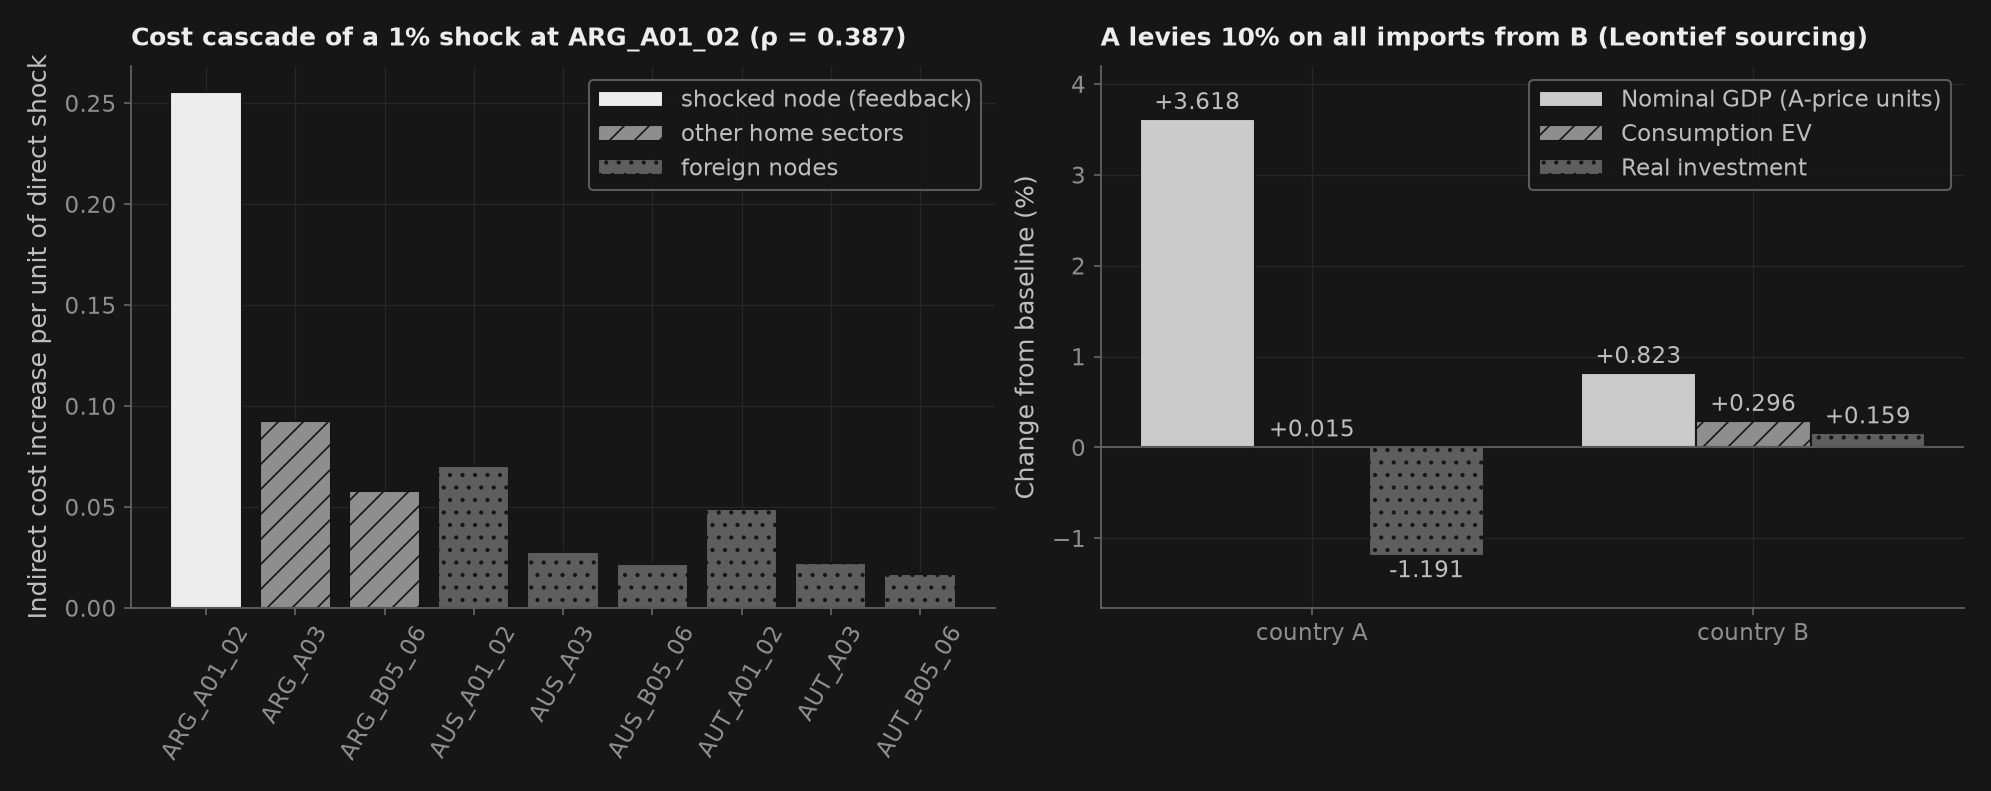

In [6]:
fig, (ax1, ax2) = _nbstyle.figura(1, 2, figsize=(13, 5))
shade = [_nbstyle.TINTA if k == shock_node else _nbstyle.BARRA_COLORES[1] if home[k] else _nbstyle.BARRA_COLORES[2]
         for k in range(n)]
hatch = ["" if k == shock_node else "//" if home[k] else ".." for k in range(n)]
bars = ax1.bar(nodes, indirect / shock_size, color=shade, edgecolor=_nbstyle.FONDO)
for bar, pattern in zip(bars, hatch):
    bar.set_hatch(pattern)
ax1.legend([bars[shock_node], bars[1], bars[-1]], ["shocked node (feedback)", "other home sectors", "foreign nodes"],
           loc="upper right", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)
ax1.tick_params(axis="x", rotation=60)
ax1.set(title=f"Cost cascade of a 1% shock at {nodes[shock_node]} (ρ = {rho:.3f})",
        ylabel="Indirect cost increase per unit of direct shock")
measures = pd.DataFrame({"Nominal GDP (A-price units)": outcomes["nominal_GDP_%"],
                         "Consumption EV": welfare_table["EV_%"],
                         "Real investment": outcomes["investment_%"]})
x = np.arange(len(measures.index))
for j, column in enumerate(measures.columns):
    ax2.bar(x + (j - 1) * 0.26, measures[column], width=0.26, label=column, color=_nbstyle.BARRA_COLORES[j],
            hatch=_nbstyle.BARRA_HATCH[j], edgecolor=_nbstyle.FONDO)
_nbstyle.etiquetar_barras(ax2, fmt="{:+.3f}")
ax2.axhline(0, color=_nbstyle.SPINE, linewidth=.8)
ax2.margins(y=0.12)
ax2.set_xticks(x, [f"country {code}" for code in measures.index])
ax2.set(title="A levies 10% on all imports from B (Leontief sourcing)", ylabel="Change from baseline (%)")
ax2.legend(loc="upper right", frameon=True, facecolor=_nbstyle.FONDO, edgecolor=_nbstyle.SPINE)

## Lectura de los resultados

**La cascada.** El radio espectral es 0.3870 y la cota superior certifica que es menor que uno, así que la serie de costos converge; las brechas ronda a ronda se reducen aproximadamente en ese factor (0.3876 por ronda), como anticipa la matemática. Un aumento de costos de 1% en ARG_A01_02 eleva el costo unitario de ese mismo nodo en 1.2555% cuando la red se lo devuelve, y la transmisión sumada sobre los nueve nodos es 1.6143. En el panel izquierdo, la retroalimentación al nodo afectado es la barra individual más alta, pero un tercio del aumento indirecto (33.9%) recae en nodos extranjeros: un choque de costos local es también un choque de costos importado para los socios comerciales. Las tres estructuras de proveedores dan la misma respuesta porque son la misma red, no porque tres bases de datos coincidan.

**El arancel.** A recauda 3.8102 en aranceles y su PIB nominal sube 3.6183%, pero su EV de consumo es solo 0.0147% del consumo inicial (0.0069 en unidades monetarias). El PIB suma la recaudación, que pagan los propios compradores de A, así que no es una medida de bienestar. Con abastecimiento Leontief, los compradores de A no pueden pasar de los bienes de B a los de A, así que A no puede trasladar el arancel a B. Los precios relativos de los factores se mueven a favor de B: el salario de B sube a 1.0197 veces el de A y el precio al productor de B a 1.0074 veces el de A. El arancel empeora los términos de intercambio del país que lo impone, lo contrario del resultado de libro de texto del arancel óptimo, y B, el país que enfrenta el arancel, gana 0.2959% de su consumo. Con A como numerario, la atribución cuenta la misma historia: la transferencia fiscal de A (+2.1409) compensa aproximadamente los mayores precios de comprador (−1.6641) y el menor ingreso factorial (−0.4698).

**Consumo frente a inversión.** Las dos EV de consumo son positivas, pero esto no es una ganancia de eficiencia mundial. La producción está fija, así que la ganancia mundial de consumo (+0.2137 canastas) es exactamente la pérdida mundial de inversión (−0.2137). La canasta de inversión de A compra a B 15 de sus 23 unidades, frente a 15 de 45 en su canasta de consumo, así que el arancel eleva el precio de la inversión de A en 7.0495% y el de su consumo en 3.6031%; con participaciones nominales de gasto fijas, la inversión real de A cae 1.1913%. Una EV que solo mira el consumo cuenta como ganancia un consumo comprado a costa de la inversión.

**Qué sobrevive al cambio de etiquetas.** Con el cierre de ingreso mundial, la EV y `EV_%` son idénticas sea cual sea el país listado primero. Los términos de precios, ingreso factorial y transferencias no lo son: el efecto precio de A es −1.6641 con A como numerario y −1.3194 con B como numerario, y solo su suma es invariante. El PIB nominal tampoco es invariante (el cambio de A es 3.6183% o 2.8615%), así que las barras de PIB del panel derecho dependen del numerario y las de EV no. Con el cierre del ahorro externo fijo en unidades del numerario, hasta el signo de la EV de A depende de la etiqueta: +0.0019% con A primero, −0.1864% con B primero.

## Tu turno

Sustituye el abastecimiento Leontief por abastecimiento CES de los insumos intermedios. `sigma` es la elasticidad de sustitución entre orígenes en las compras intermedias; las canastas de uso final siguen siendo de coeficientes fijos. La celda resuelve el arancel de 10% de A con tu `sigma` dos veces, una con cada país listado primero, bajo el cierre de ingreso mundial. Rango anunciado: de 0 a 0.3 o de 1 a 5. Entre ambos, esta tabla tiene un punto singular cerca de 0.45: allí cambia de signo la respuesta de los términos de intercambio a un arancel pequeño, la solución con 10% no converge cerca de él, y las EV que sí convergen en su vecindad son muy grandes y no son cifras de política creíbles.

1. **Básico.** Predice quién gana con el valor por defecto `sigma = 2.0` antes de ejecutar, y luego prueba 1 y 5. ¿Hacia dónde se mueve ahora el precio relativo de B, y por qué A puede trasladar parte del arancel a B cuando sus compradores pueden sustituir los bienes de B?
2. **Intermedio.** Fija `sigma = 0.2` y luego `0.3`. El precio relativo de B sigue subiendo. ¿Por qué ahora A pierde, y más que con `sigma = 0`, aunque sigue recaudando el arancel? Compara la EV de A con el cambio de su PIB nominal a partir de `cf_you.gdp` y `base_you.gdp`.
3. **Avanzado.** En una celda nueva, recorre `sigma` en (0.4, 0.44, 0.46, 0.5, 0.6) con `tariff_experiment(sigma=s, rate=1e-3)` y registra la respuesta a un arancel pequeño, $\ln(p_B/p_A)/0.001$. Luego prueba `rate=0.10` dentro de `try`/`except`. Ubica el cambio de signo y explica por qué una EV enorme que converge junto a él no es evidencia. Por último, llama a `tariff_experiment` con `closure="numeraire"` para ambos órdenes de países con un mismo `sigma`: ¿qué aserción de la celda siguiente fallaría, y por qué?

In [7]:
sigma = 2.0  # ← change this: sourcing elasticity, 0 to 0.3 or 1 to 5
assert 0 <= sigma <= 0.3 or 1 <= sigma <= 5, "this table is near-singular for sigma between 0.3 and 1"
you = {order: tariff_experiment(order, sigma=sigma) for order in (("A", "B"), ("B", "A"))}
calib_you, base_you, cf_you, w_you = you[("A", "B")]
p_you = cf_you.p_sol.ravel()
p_ratio_you = p_you[1] / p_you[0]
print(f"sigma = {sigma}: B's relative price {p_ratio_you:.4f}; EV % of consumption: "
      f"A {w_you['A'].ev_pct_consumption:+.4f}, B {w_you['B'].ev_pct_consumption:+.4f}")
for code in "AB":  # relabelling invariance under the world-income closure
    assert abs(you[("A", "B")][3][code].ev - you[("B", "A")][3][code].ev) < 1e-8
assert (p_ratio_you > 1) == (sigma < 0.45)  # inelastic sourcing: A's duty raises B's relative price
assert (p_ratio_you > 1) == (w_you["B"].ev > 0)  # B gains exactly when its terms of trade improve

sigma = 2.0: B's relative price 0.9484; EV % of consumption: A +2.6557, B -2.1767


## ¿Qué tan exhaustivo es esto?

`docs/trade_welfare.md` resuelve la misma tabla y documenta la función de bienestar, y `docs/trade_accounting.md` explica la contabilidad consistente, el numerario y los cierres de `foreign_saving_units`. El cuaderno 62 resuelve un equilibrio arancelario con contabilidad consistente y abastecimiento intermedio CES, el cuaderno 63 busca aranceles óptimos y de Nash con un objetivo de EV hicksiana (este cuaderno no calcula ningún equilibrio de Nash), y el cuaderno 64 acota radios espectrales y estudia puntos singulares del solucionador. Este cuaderno no valida la lectura de archivos nativos de insumo-producto multirregional (MRIO), comparaciones empíricas de bienestar entre bases de datos ni una descomposición causal de términos de intercambio y eficiencia; las etiquetas históricas TOT/Alloc (términos de intercambio/eficiencia asignativa) siguen sin estar disponibles. Consulta `docs/STRUCTURAL_VALIDATION_STATUS.md` para los límites de validación actuales.